<a href="https://colab.research.google.com/github/Vivek-afk81/LLM_from_scratch/blob/main/coding_124m_gpt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/My Drive/build_llm_from_scratch")

#Coding the GPT model

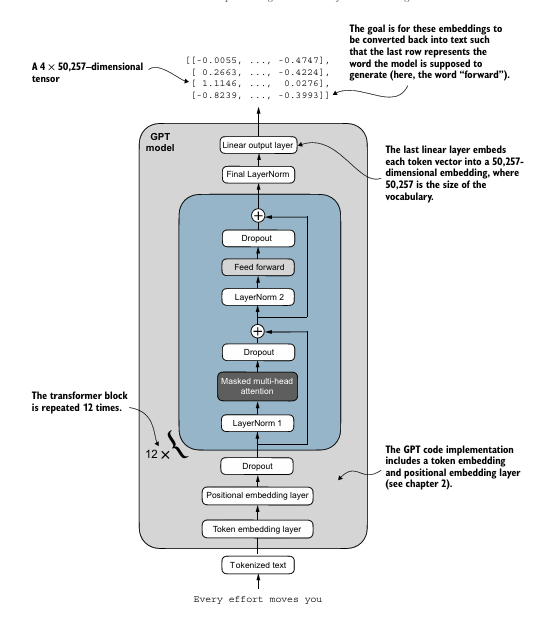

In [ ]:
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn

In [ ]:
GPT_CONFIG_124M ={
    "vocab_size" : 50257,
    "context_length":1024,
    "emb_dim":768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias":False
}

In [ ]:
texts = [
    "Hello, how are you?",
    "I love learning about transformers."
]

In [ ]:
import tiktoken
import torch

enc = tiktoken.get_encoding("gpt2")
encoded = [enc.encode(t) for t in texts]

max_len = max(len(seq) for seq in encoded)
pad_token_id = enc.eot_token

padded = [
    seq + [pad_token_id] * (max_len - len(seq))
    for seq in encoded
]

batch = torch.tensor(padded)


##Multi Head Attention

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self,d_in,d_out,
               context_length,dropout,num_heads,qkv_bias=False):
    super().__init__()

    assert (d_out % num_heads==0),\
    "d_out must be divisible by num_heads"

    self.d_out=d_out
    self.num_heads=num_heads
    self.head_dim=d_out//num_heads

    self.W_query=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_key=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value=nn.Linear(d_in,d_out,bias=qkv_bias)

    self.out_proj=nn.Linear(d_out,d_in)
    self.dropout=nn.Dropout(dropout)
    self.register_buffer(
         "mask",
    torch.triu(torch.ones(context_length, context_length),
               diagonal=1)
    )

  def forward(self,x):
    b,num_tokens,d_in=x.shape
    keys=self.W_key(x)
    queries=self.W_query(x)
    values=self.W_value(x)

    keys=keys.view(b,num_tokens,self.num_heads,self.head_dim)
    values=values.view(b,num_tokens,self.num_heads,self.head_dim)
    queries = queries.view(
    b, num_tokens, self.num_heads, self.head_dim
    )

    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)

    attn_scores=queries@ keys.transpose(2,3)
    mask_bool=self.mask.bool()[:num_tokens,:num_tokens]

    attn_scores.masked_fill_(mask_bool,-torch.inf)

    attn_weights= torch.softmax(
         attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vec=(attn_weights @values).transpose(1,2)
    context_vec = context_vec.contiguous().view(
    b, num_tokens, self.d_out
    )
    context_vec = self.out_proj(context_vec)
    return context_vec


##Layer Normalization

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

## A feed forward neural network module

In [ ]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
          torch.sqrt(torch.tensor(2.0 / torch.pi)) *
          (x + 0.044715 * torch.pow(x, 3))
      ))

In [ ]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
      super().__init__()
      self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

  def forward(self, x):
    return self.layers(x)

##Transformer block

In [ ]:
class TransformerBlock (nn.Module):
  def __init__(self,cfg):
    super().__init__()

    self.att=MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_length=cfg["context_length"],
        num_heads=cfg["n_heads"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"]
    )
    self.ff=FeedForward(cfg)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self,x):
    shortcut=x
    self.norm1(x)
    x=self.att(x)
    x=self.drop_shortcut(x)
    x=x+shortcut

    shortcut=x
    x=self.norm2(x)
    x=self.ff(x)
    x=self.drop_shortcut(x)
    x=x+shortcut
    return x


In [ ]:
class GPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()

    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])

    self.trf_blocks=nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )

    self.final_norm=LayerNorm(cfg["emb_dim"])
    self.out_head=nn.Linear(
        cfg["emb_dim"],cfg["vocab_size"],bias=False
    )

  def forward(self,in_idx):
    batch_size,seq_len=in_idx.shape
    tok_embeds=self.tok_emb(in_idx)

    pos_embeds=self.pos_emb(
         torch.arange(seq_len, device=in_idx.device)
    )

    x=tok_embeds+pos_embeds
    x=self.drop_emb(x)
    x=self.trf_blocks(x)
    x=self.final_norm(x)
    logits=self.out_head(x)
    return logits

In [ ]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)

out=model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[15496,    11,   703,   389,   345,    30, 50256],
        [   40,  1842,  4673,   546,  6121,   364,    13]])

Output shape: torch.Size([2, 7, 50257])
tensor([[[ 0.0592, -0.7927,  0.5976,  ...,  0.4993,  0.2780, -1.1534],
         [ 0.0310, -0.8664, -0.2364,  ...,  0.5441,  0.8690, -0.1736],
         [-0.3563, -0.7907, -0.0776,  ...,  1.0032,  0.6710,  0.1466],
         ...,
         [ 0.0051, -0.7435, -0.0621,  ...,  0.1649,  0.4418, -0.7716],
         [-0.6933, -0.4077, -0.1117,  ...,  0.4201,  0.5008, -0.6144],
         [-0.6314, -0.3506, -0.1348,  ...,  0.6823, -0.1664,  0.1396]],

        [[ 0.3435, -0.1114,  0.9431,  ..., -0.4757,  0.4793, -0.6660],
         [ 0.2770, -0.0690,  0.4966,  ..., -0.4264,  0.0531, -0.8593],
         [ 0.9506,  0.6880,  0.3240,  ...,  0.2278, -0.3754, -0.1470],
         ...,
         [ 0.6939,  0.5276,  0.5824,  ..., -0.3012, -0.6920, -0.7355],
         [-0.4782, -0.3583,  0.1992,  ..., -0.0164,  1.0229, -1.0693],
         [-0.46

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


the actual number of parameters is
163 million because of a concept called "**weight tying**" the original GPT-2 architecture reuses the weights from
the token embedding layer in its output layer


In [ ]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [ ]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
      f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


let’s compute the memory requirements of the 163 million parameters in our
GPTModel object

In [ ]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB
